# Classwork: Curve of Best Fit

1. Read through the description for the [Curve of Best Fit](https://nchs-cs.github.io/idp/visualizations/curve_of_best_fit.html)
2. Complete the TODO in the code below and show the correct plot output to complete this activity.


RMSE Degree2: 88.35854461478638  RMSE Degree1: 0.0


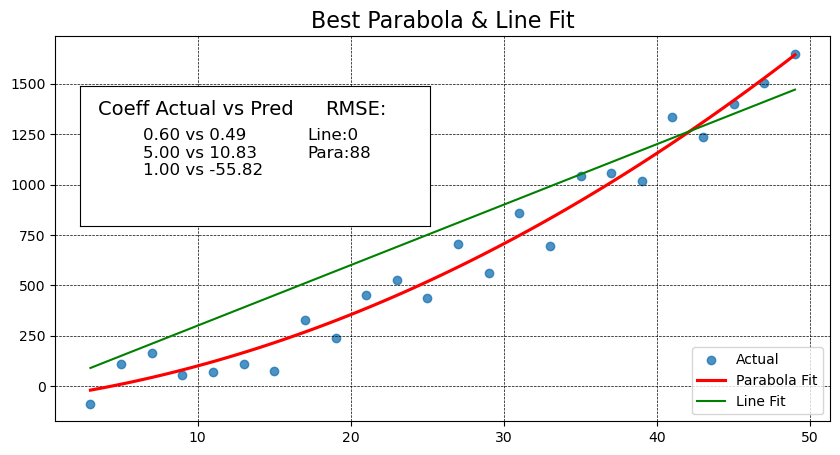

In [11]:
import random
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

def add_inset_text(fig, position, actual, coeffs):
    # print values in an inset positioned in figure percentages [x, y, width, height]
    ax_inset = fig.add_axes(position)
    ax_inset.set_xlabel('')
    ax_inset.set_ylabel('')
    ax_inset.set_xticks([])
    ax_inset.set_yticks([])
    ax_inset.grid(False)
    text = 'Coeff Actual vs Pred'
    ax_inset.text(0.05, 0.90, text, ha='left', va='top', fontsize=14)
    text = ''
    for a, c in zip(actual, coeffs):
        text += f'{a:.2f} vs {c:.2f}\n'
    ax_inset.text(0.18, .70, text, ha='left', va='top', fontsize=12)
    return ax_inset
    
    
def best_parabola_fit():
    def parabola(x, a, b, c):
        y = a*x**2 + b*x + c
        return y

    def generate_points(a, b, c, noise):
        x_data = [ x for x in range(3, 50, 2) ]
        y_data = [ parabola(x, a, b, c) + random.randint(-noise, noise) for x in x_data]
        return x_data, y_data
    
    # establish our True parabola coefficients
    actual = (0.6, 5, 1)
    noise = 150
    x_data, y_data = generate_points(*actual, noise)
    
    # plot it all
    fig, ax = plt.subplots(figsize=(10,5))

    # Use the grid in the plot and set the line style to black & dashed
    plt.grid(True, linestyle='--', linewidth=0.5, color='black')
    
    # Eliminate the confidence interval shading of the parabola and color the line red
    sns.regplot(x=x_data, y=y_data, ax=ax, order=2, ci=None, line_kws={'color':'red'})
    
    # Determine if a linear line is a better fit using MSE
    # find the coefficients of the parabola that best fits the points generated
    # The coefficients are ordered from high order to lower order
    coeffs_2 = np.polyfit(x_data, y_data, 2)
    y_predicted_2 = [ coeffs_2[0]*x**2 + coeffs_2[1]*x + coeffs_2[2] for x in x_data]
    mse_degree_2 = mean_squared_error(y_data, y_predicted_2)
    
    #  get coefficients for the line
    
    # TODO: similar to above - get the coefficients for the line,
    # then calculate the predicted y values and MSE for the line, 
    # and print out the RMSE for both the line as well.
    y_predicted_1 = [ 30*x + 1 for x in x_data] # Change to use np cooefficients here when you get them
    mse_degree_1 = 0 # Change to calculate MSE for the line here when you get the coefficients
    print('RMSE Degree2:',  np.sqrt(mse_degree_2), ' RMSE Degree1:', np.sqrt(mse_degree_1))
    
    # add MSE to our inset text box
    ax_inset = add_inset_text(fig, [0.15, 0.50, 0.35, 0.28], actual, coeffs_2)
    ax_inset.text(0.7, 0.90, 'RMSE:', ha='left', va='top', fontsize=14)
    text = f'Line:{np.sqrt(mse_degree_1):.0f}\nPara:{np.sqrt(mse_degree_2):.0f}'
    ax_inset.text(0.65, .70, text, ha='left', va='top', fontsize=12)
    
    # since plt.plot() does not offer ax=ax argument, and without it we plot on the inset,
    # use ax.plot() to get the line to show up on the right axis.
    ax.plot(x_data, y_predicted_1, color="green")
    ax.set_title('Best Parabola & Line Fit', fontsize=16)
    
    # Need to set the legend on the axis to get things to show up correctly,
    # even when setting label=''values' during plots, we need to set the label strings here.
    ax.legend(['Actual', 'Parabola Fit', 'Line Fit', ], loc='lower right')

best_parabola_fit()